# Step 5. 센서 ID ↔ 공정 매핑 시나리오 — 해석을 '조치'로 연결

**목표**: SHAP이 찾은 핵심 센서(`sensor_xxx`)는 익명화되어 물리적 의미가 없다. 여기에 **가상의 공정 의미를 매핑**하고, SHAP의 영향 방향(값↑일 때 불량↑/↓)을 결합해 *"어떤 공정 파라미터를 어떻게 관리해야 하는가"* 라는 PE 관점의 조치 제안까지 연결한다.

> ⚠️ **중요 — 본 매핑은 전부 '가정(assumption)'이다.** SECOM 원본은 센서의 실제 의미를 공개하지 않는다. 이 노트북은 *실제 팹이라면 sensor_id를 공정 트레이서빌리티 시스템과 매핑해 이런 흐름으로 활용한다*는 **시나리오를 시연**하기 위한 것이다. 매핑된 공정명/물리량은 임의의 예시이며 사실이 아니다.

**구성**
1. 모델·데이터 로드 → SHAP 재계산
2. 상위 센서의 **영향 방향**을 데이터로 계산 (값↑ → 불량↑ 인지 ↓ 인지)
3. 가상 공정 매핑 테이블 결합 → 관리 조치 도출
4. 공정 매핑 시각화

## 0. 설정 · 로드 · SHAP 재계산

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib
import shap

# 한글+마이너스 모두 지원하는 폰트 사용 (방향 표기에 음수/부호가 섞임)
sns.set_style('whitegrid')
mpl.rcParams['font.family'] = 'Arial Unicode MS'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

FIG_DIR = os.path.join('..', 'outputs', 'figures')
PROC_DIR = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'outputs', 'models')
OUT_DIR = os.path.join('..', 'outputs')
print('준비 완료')

준비 완료


In [2]:
# 선택 모델(RF)과 test 데이터 로드 후 SHAP 값 계산 (Step 4와 동일 로직)
bundle = joblib.load(os.path.join(MODEL_DIR, 'random_forest.joblib'))
model = bundle['model']

data = np.load(os.path.join(PROC_DIR, 'secom_processed.npz'), allow_pickle=True)
X_test = data['X_test']
feature_names = list(data['feature_names'])
X_test_df = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_test_df)
if isinstance(sv, list):
    shap_vals = sv[1]
elif sv.ndim == 3:
    shap_vals = sv[:, :, 1]
else:
    shap_vals = sv
print('SHAP shape:', shap_vals.shape)

SHAP shape: (314, 450)


## 1. 상위 센서의 영향 방향을 데이터로 계산

**방향**은 가정이 아니라 데이터에서 나온다. 각 센서의 *값*과 *SHAP 값* 사이 상관(corr)을 보면:
- corr > 0 → **센서 값이 높을수록 불량 위험↑** (→ 상한 관리)
- corr < 0 → **센서 값이 낮을수록 불량 위험↑** (→ 하한 관리)

In [3]:
# 평균 |SHAP| 기준 상위 12개 센서 + 방향(값-SHAP 상관) 계산
TOP_N = 12
mean_abs = np.abs(shap_vals).mean(axis=0)
order = np.argsort(mean_abs)[::-1][:TOP_N]

rows = []
for rank, j in enumerate(order, 1):
    vals = X_test_df.iloc[:, j].values
    # 값과 SHAP의 상관 → 영향 방향
    corr = np.corrcoef(vals, shap_vals[:, j])[0, 1]
    direction = '값↑ → 불량↑' if corr >= 0 else '값↑ → 불량↓'
    rows.append({'rank': rank, 'sensor': feature_names[j],
                 'mean_abs_shap': round(float(mean_abs[j]), 5),
                 'corr(값,SHAP)': round(float(corr), 3),
                 'direction': direction})

dir_df = pd.DataFrame(rows).set_index('rank')
print('상위 센서 영향 방향 (데이터 기반)')
print(dir_df.to_string())

상위 센서 영향 방향 (데이터 기반)
          sensor  mean_abs_shap  corr(값,SHAP) direction
rank                                                   
1     sensor_519        0.01761         0.503  값↑ → 불량↑
2     sensor_095        0.01678         0.738  값↑ → 불량↑
3     sensor_511        0.01568         0.845  값↑ → 불량↑
4     sensor_247        0.01423         0.520  값↑ → 불량↑
5     sensor_059        0.01416         0.817  값↑ → 불량↑
6     sensor_345        0.01307         0.385  값↑ → 불량↑
7     sensor_033        0.01154         0.249  값↑ → 불량↑
8     sensor_385        0.01049         0.486  값↑ → 불량↑
9     sensor_103        0.01007         0.808  값↑ → 불량↑
10    sensor_031        0.01006        -0.797  값↑ → 불량↓
11    sensor_486        0.00991         0.673  값↑ → 불량↑
12    sensor_205        0.00829         0.481  값↑ → 불량↑


## 2. 가상 공정 매핑 테이블 결합

아래 `PROCESS_MAP`은 **임의로 가정한 예시**다(실제 팹의 매핑 테이블을 대신하는 시연용). 실제 환경에서는 이 자리에 MES/트레이서빌리티 시스템의 실제 계측 항목이 들어간다.

In [4]:
# === 가정(예시) 매핑 — 사실 아님, 시나리오 시연용 ===
# 실제 팹이라면 sensor_id마다 (공정단계, 물리량)이 트레이서빌리티 DB에 정의되어 있음
PROCESS_MAP = {
    'sensor_519': ('Etch(식각)', '챔버 압력'),
    'sensor_095': ('Deposition(증착)', '히터 온도'),
    'sensor_511': ('Etch(식각)', 'RF 파워'),
    'sensor_247': ('CMP(연마)', '슬러리 유량'),
    'sensor_059': ('Photo(노광)', '노광 시간'),
    'sensor_345': ('Deposition(증착)', '가스 유량'),
    'sensor_033': ('Diffusion(확산)', '퍼니스 온도'),
    'sensor_385': ('Implant(이온주입)', '빔 전류'),
    'sensor_103': ('Cleaning(세정)', '약액 농도'),
    'sensor_031': ('Photo(노광)', '포커스'),
    'sensor_486': ('CMP(연마)', '패드 압력'),
    'sensor_205': ('Metrology(계측)', '막두께'),
}

def make_action(direction):
    # 영향 방향에 따른 관리 조치 제안
    if '불량↑' in direction:
        return '상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지'
    return '하한 관리 강화 (값이 낮을 때 위험) → SPC 하한선·이상감지'

scenario = dir_df.copy()
scenario['(가정)공정단계'] = scenario['sensor'].map(lambda s: PROCESS_MAP.get(s, ('(미지정)', '-'))[0])
scenario['(가정)물리량'] = scenario['sensor'].map(lambda s: PROCESS_MAP.get(s, ('(미지정)', '-'))[1])
scenario['관리 조치 제안'] = scenario['direction'].map(make_action)

view = scenario[['sensor', '(가정)공정단계', '(가정)물리량', 'direction', '관리 조치 제안']]
print('★ 센서 → 공정 매핑 시나리오 (가정 기반)')
print(view.to_string())

# 포트폴리오 첨부용으로 CSV 저장
csv_path = os.path.join(OUT_DIR, 'process_mapping_scenario.csv')
scenario.to_csv(csv_path, encoding='utf-8-sig')
print('\n저장:', csv_path)

★ 센서 → 공정 매핑 시나리오 (가정 기반)
          sensor        (가정)공정단계 (가정)물리량 direction                              관리 조치 제안
rank                                                                                    
1     sensor_519        Etch(식각)   챔버 압력  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지
2     sensor_095  Deposition(증착)   히터 온도  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지
3     sensor_511        Etch(식각)   RF 파워  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지
4     sensor_247         CMP(연마)  슬러리 유량  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지
5     sensor_059       Photo(노광)   노광 시간  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지
6     sensor_345  Deposition(증착)   가스 유량  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지
7     sensor_033   Diffusion(확산)  퍼니스 온도  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지
8     sensor_385   Implant(이온주입)    빔 전류  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·이상감지
9     sensor_103    Cleaning(세정)   약액 농도  값↑ → 불량↑  상한 관리 강화 (값이 높을 때 위험) → SPC 상한선·

## 3. 공정 매핑 시각화

상위 센서를 **영향 방향별 색**으로 칠하고, 가정 공정명을 라벨로 달아 "공정 단계별 불량 기여도"를 한눈에 보이게 한다.

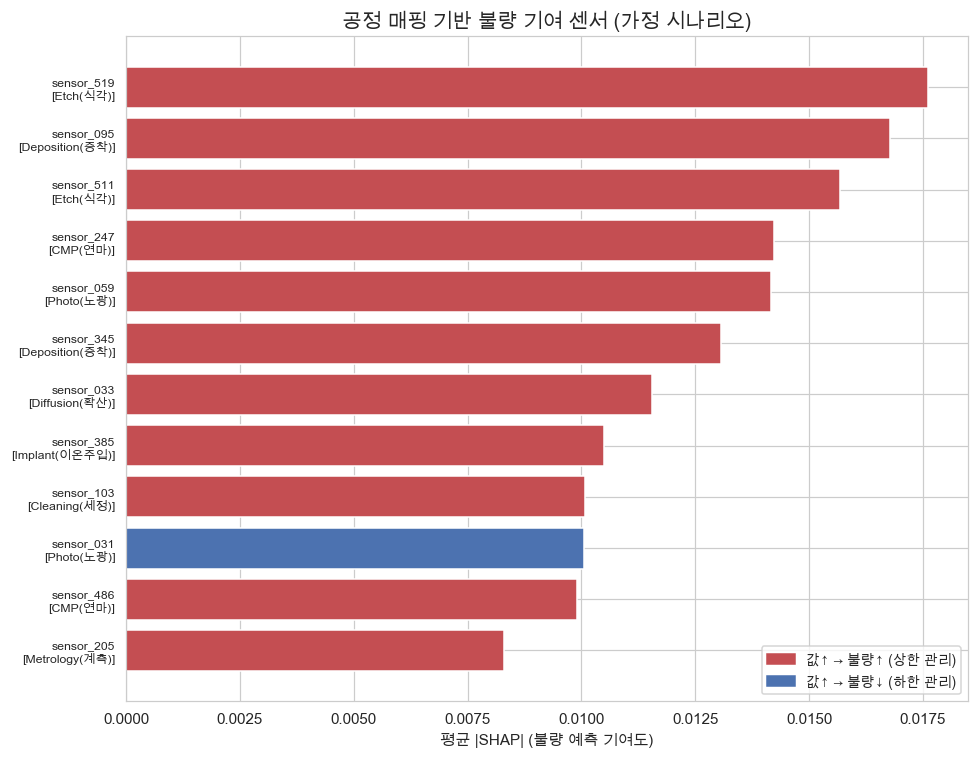

In [5]:
# 방향별 색: 값↑→불량↑(빨강), 값↑→불량↓(파랑)
colors = ['#C44E52' if '불량↑' in d else '#4C72B0' for d in scenario['direction']]
labels = [f"{s}\n[{p}]" for s, p in zip(scenario['sensor'], scenario['(가정)공정단계'])]

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(scenario))[::-1]
ax.barh(y, scenario['mean_abs_shap'], color=colors)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('평균 |SHAP| (불량 예측 기여도)')
ax.set_title('공정 매핑 기반 불량 기여 센서 (가정 시나리오)', fontsize=13)
# 범례
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C44E52', label='값↑ → 불량↑ (상한 관리)'),
                   Patch(color='#4C72B0', label='값↑ → 불량↓ (하한 관리)')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '11_process_mapping.png'), bbox_inches='tight')
plt.show()

### 포트폴리오 인사이트 (Step 5)

- **분석 → 조치로 한 걸음 더**: SHAP 중요도(센서 번호)에서 멈추지 않고, *영향 방향(데이터 기반)* + *가상 공정 매핑* + *관리 조치 제안*까지 연결해 PE 직무의 "수율 인자 식별 → 공정 관리" 흐름을 시연했다.
- **방향은 데이터, 의미는 가정**: 값↑/↓이 불량을 올리는지는 SHAP-값 상관으로 **데이터에서** 도출했고, 공정명만 가정으로 붙였다. 둘을 명확히 구분해 데이터 왜곡을 피했다.
- **실무 적용 포인트**: 상한/하한 관리는 곧 SPC 관리한계 설정, 이상감지 알람, 우선 점검 설비 선정으로 직결된다. "어떤 공정을 먼저 들여다볼지"의 우선순위를 모델이 제시하는 셈.

> 면접 화법 예: *"센서가 익명화돼 있어 실제 의미는 모르지만, 영향의 크기와 방향은 데이터로 정량화했습니다. 실제 팹이라면 이 sensor_id를 트레이서빌리티 시스템과 매핑해 곧바로 상·하한 관리 대상 공정을 선정할 수 있습니다."*